<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_121_networks_so_topic(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본 설정
- 필자 그룹별 So 문맥 비교
- 사회주의 토픽 사용 상의 차이에 주목

In [1]:
# =================================================================
# 셀 1: 필수 라이브러리 및 한글 폰트 설치
# =================================================================
# ⚠️ 이 셀을 실행한 후에는 반드시 "런타임 다시 시작"을 해야 합니다.

# 1. 라이브러리 설치 (최신 호환 버전)
!pip install -q tomotopy kneed

# 2. 나눔 폰트 설치
!sudo apt-get -qq install fonts-nanum*

# 3. 폰트 캐시 재생성
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("✅ 라이브러리 및 한글 폰트 설치가 완료되었습니다.")
print("🔴 중요: 지금 바로 메뉴에서 [런타임] > [세션 다시 시작]을 실행하세요!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 21.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the

Mounted at /content/drive

✅ 구글 드라이브 마운트 완료!
1.26.4
✅ 기본 설정 및 라이브러리 임포트 완료!


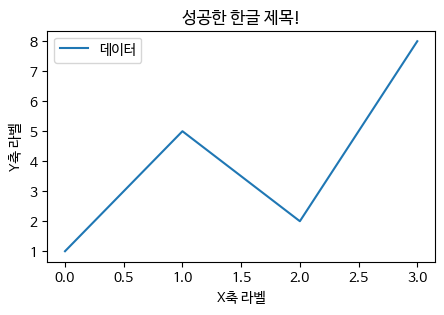

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

# 라이브러리 임포트
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

# ⚠️ 한글 폰트 설정 코드를 여기에 배치합니다.
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("✅ 기본 설정 및 라이브러리 임포트 완료!")

# 그래프 한글 표시 테스트
plt.figure(figsize=(5, 3))
plt.title('성공한 한글 제목!')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.plot([1, 5, 2, 8], label='데이터')
plt.legend()
plt.show()

# 2.데이터 불러오기

In [2]:
# 통합 데이터 불러오기
df = pd.read_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls).xlsx') ###
df[:3]
# 1기, 2기: doc_id는 3046부터 끝까지
df['period'] = np.where(
    df['doc_id'] < 3046,  # 조건
    'p1',                          # 조건이 참일 때
    'p2'                           # 조건이 거짓일 때
)
df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0,p1
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0,p1
...,...,...,...,...,...,...,...,...,...,...
6797,6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6798,6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6799,6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6800,6801,25년 전에는 영국이 美보다 배나 더 되게 輸入하엿섯음니다 캐나다 사람들은 지금 그...,영국 미국 輸入 캐나다 사람 영국 一部 미국 호주 캐나다 진화 호주 일본 침입 보호...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


In [3]:
# 저장

# df.to_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls)_period.xlsx')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6802 entries, 0 to 6801
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   doc_id            6802 non-null   int64 
 1   doc_raw           6802 non-null   object
 2   doc_split_12gram  6802 non-null   object
 3   r_no              6802 non-null   int64 
 4   title             6802 non-null   object
 5   w_new             6802 non-null   object
 6   ho_no             6802 non-null   int64 
 7   grid_1            6802 non-null   object
 8   wn_cls            6802 non-null   int64 
 9   period            6802 non-null   object
dtypes: int64(4), object(6)
memory usage: 531.5+ KB


# 3.1,2기 토픽 연결망 비교

## 3.1.'문서별 토픽비중' 불러오기
- doc-distrib.txt

In [5]:
# -*- coding: utf-8 -*-
# 개벽 주요논설 DMR 문서-토픽 분포 → 기간별(1기/2기) 토픽-토픽 코사인유사도 기반 네트워크 시각화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import re
from pathlib import Path

In [6]:
# 문서별 토픽비중 불러오기

doc_dist = pd.read_csv(file_path + 'result/doc-distrib.txt', sep='\t')
doc_dist.drop(columns=['Unnamed: 0'], inplace=True)
doc_dist['doc_id'] = doc_dist.index + 1
doc_dist.set_index('doc_id', inplace=True)
doc_dist

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
1,0.100175,0.000584,0.005788,0.000916,0.699498,0.007016,0.181811,0.004213
2,0.242115,0.000204,0.016817,0.000319,0.022108,0.313191,0.403775,0.001470
3,0.013623,0.000518,0.005135,0.000812,0.357190,0.570561,0.048423,0.003738
4,0.170529,0.000538,0.005336,0.000844,0.058408,0.671052,0.089409,0.003884
5,0.701495,0.000366,0.003632,0.000575,0.066367,0.217282,0.007639,0.002644
...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963


In [7]:
# 1,2기 구분

doc_dist_p1 = doc_dist.query('doc_id < 3046')
doc_dist_p2 = doc_dist.query('doc_id >= 3046')

## 3.2.토픽 간 유사도 산출

In [8]:
# --------------------------
# 3) 토픽-토픽 코사인유사도 계산 함수
#    (각 토픽을 '문서들에 대한 출현벡터'로 보고 토픽 간 유사도 측정)
# --------------------------
def topic_topic_cosine(df_period: pd.DataFrame, topic_cols: list[str]) -> pd.DataFrame:
    """
    df_period: 특정 기간의 문서-토픽 분포 (행=문서, 열=토픽)
    반환: 토픽-토픽 코사인유사도 행렬 (DataFrame, index/columns=topic_cols)
    """
    # X: (n_docs, n_topics) → V: (n_topics, n_docs)
    X = df_period[topic_cols].to_numpy(dtype=float, copy=True)
    V = X.T
    sim = cosine_similarity(V)  # (n_topics, n_topics)
    return pd.DataFrame(sim, index=topic_cols, columns=topic_cols)

# Define TOPIC_COLS explicitly as a list of strings
NUM_TOPICS = 8
TOPIC_COLS = [f"T{i}" for i in range(NUM_TOPICS)]

sim_p1 = topic_topic_cosine(doc_dist_p1, TOPIC_COLS) if not doc_dist_p1.empty else None
sim_p2 = topic_topic_cosine(doc_dist_p2, TOPIC_COLS) if not doc_dist_p2.empty else None

## 3.3.시각화

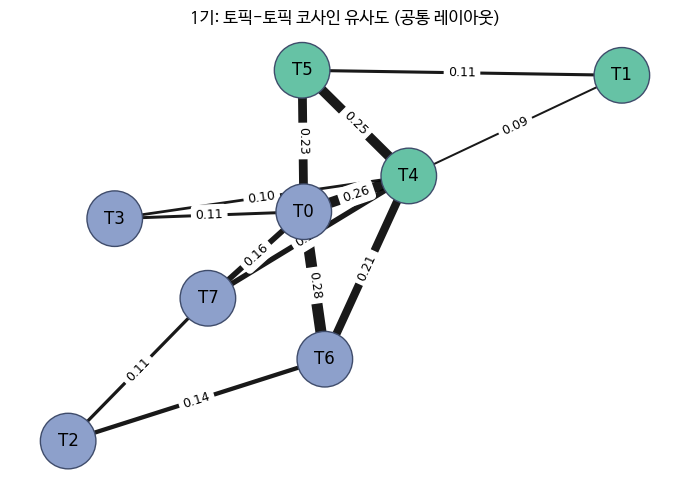

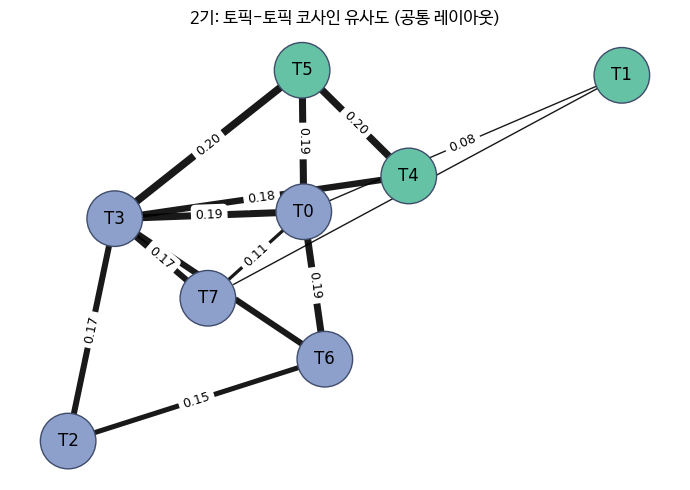

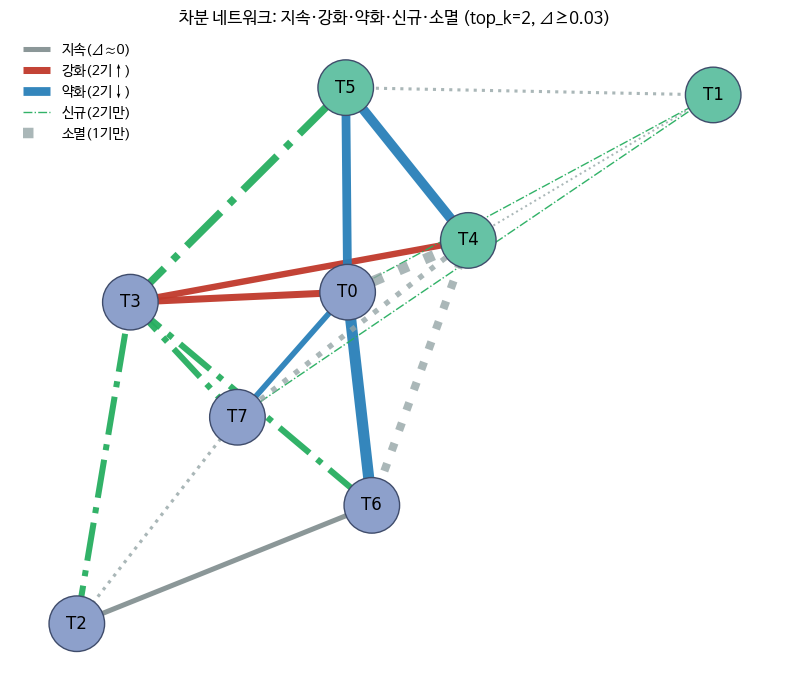

In [9]:
# ==========================================================
# [비교 시각화 도구] 공통 레이아웃 + 차분(diff) 네트워크
# sim_p1, sim_p2, TOPIC_COLS 가 이미 존재한다고 가정
# ==========================================================
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

# -----------------------------
# 0) 공통 설정
# -----------------------------
TOP_K = 2        # 노드별 상위 k개 연결(두 시기 모두 동일 규칙)
THRESH = None    # 임계값을 쓰려면 수치 지정(예: 0.15); 아니면 None
DELTA_EPS = 0.03 # 강화/약화 판별 기준(절대증감 0.03 이상이면 강조)

# -----------------------------
# 1) 유틸: 유사도에서 간선 사전 추출
# -----------------------------
def edges_from_sim(sim_df, top_k=2, threshold=None, min_sim=1e-9):
    topics = list(sim_df.index)
    pairs = []
    for i in range(len(topics)):
        for j in range(i+1, len(topics)):
            w = float(sim_df.iloc[i, j])
            if w >= min_sim:
                pairs.append((topics[i], topics[j], w))
    # threshold 적용
    if threshold is not None:
        pairs = [(u, v, w) for (u, v, w) in pairs if w >= threshold]
    # top-k 적용(노드별)
    if top_k is not None and top_k > 0:
        keep = set()
        by_node = {}
        for u, v, w in pairs:
            by_node.setdefault(u, []).append((v, w))
            by_node.setdefault(v, []).append((u, w))
        for node, neighs in by_node.items():
            neighs.sort(key=lambda x: x[1], reverse=True)
            for v, w in neighs[:top_k]:
                keep.add(tuple(sorted((node, v))) + (w,))
        pairs = list(keep)
    # dict: ('T0','T6')-> weight
    E = {tuple(sorted((u, v))): w for u, v, w in pairs}
    return E

E1 = edges_from_sim(sim_p1, top_k=TOP_K, threshold=THRESH)
E2 = edges_from_sim(sim_p2, top_k=TOP_K, threshold=THRESH)
nodes = list(sim_p1.index)  # ['T0'..'T7']

# -----------------------------
# 2) 공통 레이아웃(두 시기 동일 좌표)
#    - 두 시기의 간선 합집합에 평균 가중치로 레이아웃 계산
# -----------------------------
G_union = nx.Graph()
G_union.add_nodes_from(nodes)
for uv in set(E1) | set(E2):
    w_avg = 0.5 * (E1.get(uv, 0.0) + E2.get(uv, 0.0))
    G_union.add_edge(*uv, weight=w_avg)

pos = nx.spring_layout(G_union, seed=42, weight="weight")  # 고정 레이아웃

# (선택) 커뮤니티 탐지(합집합 그래프 기준) → 색상 일관 유지
communities = list(greedy_modularity_communities(G_union, weight="weight"))
color_map = {}
palette = ["#8da0cb", "#66c2a5", "#fc8d62", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
for ci, comm in enumerate(communities):
    for n in comm:
        color_map[n] = palette[ci % len(palette)]
node_colors = [color_map.get(n, "#DCE6F2") for n in nodes]  # 커뮤니티 색(없으면 기본)

# -----------------------------
# 3) 보조: 스케일러(두 시기 공통 폭)
# -----------------------------
def width_scale(w, wmin, wmax):
    if wmax <= wmin + 1e-12:
        return 3.0
    return 1.0 + 7.0 * (w - wmin) / (wmax - wmin)

global_w = list(E1.values()) + list(E2.values())
wmin, wmax = (min(global_w), max(global_w)) if global_w else (0.0, 1.0)

# -----------------------------
# 4) 패널 그리기(동일 좌표)
# -----------------------------
def draw_panel(E, title):
    G = nx.Graph()
    G.add_nodes_from(nodes)
    for (u, v), w in E.items():
        G.add_edge(u, v, weight=w)

    plt.figure(figsize=(7, 5))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors="#3F4C6B", node_size=1600)
    nx.draw_networkx_labels(G, pos, font_size=12)
    widths = [width_scale(d["weight"], wmin, wmax) for *_, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.9)
    # 간선 라벨(혼잡하면 주석 처리)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_panel(E1, "1기: 토픽-토픽 코사인 유사도 (공통 레이아웃)")
draw_panel(E2, "2기: 토픽-토픽 코사인 유사도 (공통 레이아웃)")

# -----------------------------
# 5) 차분(diff) 네트워크(한 장에 지속/변화 표현)
# -----------------------------
# 분류: 지속(두 시기 모두), 강화(Δ>EPS), 약화(Δ<-EPS), 소멸(1기만), 신규(2기만)
edges_all = sorted(list(set(E1) | set(E2)))
cat_edges = {"persist": [], "up": [], "down": [], "gone": [], "new": []}
for uv in edges_all:
    w1, w2 = E1.get(uv, 0.0), E2.get(uv, 0.0)
    if (uv in E1) and (uv in E2):
        delta = w2 - w1
        if delta > DELTA_EPS:
            cat_edges["up"].append((uv, w1, w2))
        elif delta < -DELTA_EPS:
            cat_edges["down"].append((uv, w1, w2))
        else:
            cat_edges["persist"].append((uv, w1, w2))
    elif uv in E1 and uv not in E2:
        cat_edges["gone"].append((uv, w1, w2))
    elif uv not in E1 and uv in E2:
        cat_edges["new"].append((uv, w1, w2))

plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G_union, pos, node_color=node_colors, edgecolors="#3F4C6B", node_size=1600)
nx.draw_networkx_labels(G_union, pos, font_size=12)

def draw_edges(items, color, style="solid", alpha=0.95, label=None):
    if not items:
        return
    es = []
    widths = []
    for (u, v), w1, w2 in items:
        es.append((u, v))
        # 두께는 두 시기 중 큰 값 기준(강도 표현)
        w = max(w1, w2)
        widths.append(width_scale(w, wmin, wmax))
    nx.draw_networkx_edges(G_union, pos, edgelist=es,
                           width=widths, edge_color=color, style=style, alpha=alpha, label=label)

draw_edges(cat_edges["persist"], "#7f8c8d", "solid", 0.9, "지속(Δ≈0)")
draw_edges(cat_edges["up"],      "#c0392b", "solid", 0.95, "강화(2기↑)")
draw_edges(cat_edges["down"],    "#2980b9", "solid", 0.95, "약화(2기↓)")
draw_edges(cat_edges["new"],     "#27ae60", "dashdot", 0.95, "신규(2기만)")
draw_edges(cat_edges["gone"],    "#95a5a6", "dotted", 0.8, "소멸(1기만)")

plt.legend(loc="upper left", frameon=False)
plt.title(f"차분 네트워크: 지속·강화·약화·신규·소멸 (top_k={TOP_K}, Δ≥{DELTA_EPS})")
plt.axis("off"); plt.tight_layout(); plt.show()


## 3.4.소결
- 2기로 오면서 So 토픽(T3)이 중심에 진입하는 모습이 분명
- 이 토픽연결망은 개벽의 논조에 상응하는 이미지로 볼 수 있다.

# The End of Note